Zadanie 8

Wariant 1: early_stopping=False
Epoki: 155
Czas: 0.1919 sekund
Accuracy: 0.9737

Wariant 2: early_stopping=True
Epoki: 29
Czas: 0.0383 sekund
Accuracy: 0.9649

Tabela porownawcza:
                Wariant  Epoki  Czas (sekundy)  Accuracy
0  early_stopping=False    155        0.191928  0.973684
1   early_stopping=True     29        0.038277  0.964912


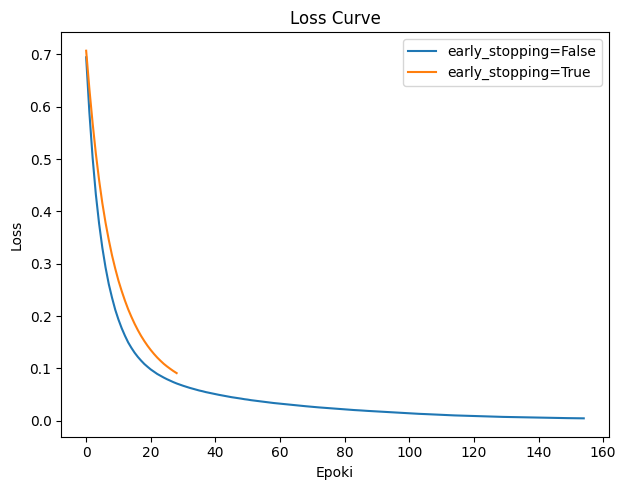

In [5]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

hidden_layer_sizes = (64, 32)
solver = 'adam'
max_iter = 1000

mlp_no_early_stopping = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes,
                                      solver=solver,
                                      max_iter=max_iter,
                                      early_stopping=False,
                                      random_state=42)
start_time = time.time()
mlp_no_early_stopping.fit(X_train, y_train)
end_time = time.time()
time_no_early_stopping = end_time - start_time
y_pred_no_early_stopping = mlp_no_early_stopping.predict(X_test)
accuracy_no_early_stopping = accuracy_score(y_test, y_pred_no_early_stopping)

mlp_early_stopping = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes,
                                  solver=solver,
                                  max_iter=max_iter,
                                  early_stopping=True,
                                  validation_fraction=0.15,
                                  random_state=42)
start_time = time.time()
mlp_early_stopping.fit(X_train, y_train)
end_time = time.time()
time_early_stopping = end_time - start_time
y_pred_early_stopping = mlp_early_stopping.predict(X_test)
accuracy_early_stopping = accuracy_score(y_test, y_pred_early_stopping)

print("Wariant 1: early_stopping=False")
print(f"Epoki: {mlp_no_early_stopping.n_iter_}")
print(f"Czas: {time_no_early_stopping:.4f} sekund")
print(f"Accuracy: {accuracy_no_early_stopping:.4f}")
print("\nWariant 2: early_stopping=True")
print(f"Epoki: {mlp_early_stopping.n_iter_}")
print(f"Czas: {time_early_stopping:.4f} sekund")
print(f"Accuracy: {accuracy_early_stopping:.4f}")

import pandas as pd
results = {
    'Wariant': ['early_stopping=False', 'early_stopping=True'],
    'Epoki': [mlp_no_early_stopping.n_iter_, mlp_early_stopping.n_iter_],
    'Czas (sekundy)': [time_no_early_stopping, time_early_stopping],
    'Accuracy': [accuracy_no_early_stopping, accuracy_early_stopping]
}
results_df = pd.DataFrame(results)
print("\nTabela porownawcza:")
print(results_df)

plt.figure(figsize=(12, 5)) 
plt.subplot(1, 2, 1)
plt.plot(mlp_no_early_stopping.loss_curve_, label='early_stopping=False')
plt.plot(mlp_early_stopping.loss_curve_, label='early_stopping=True')
plt.title('Loss Curve')
plt.xlabel('Epoki')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()


Zadanie 18

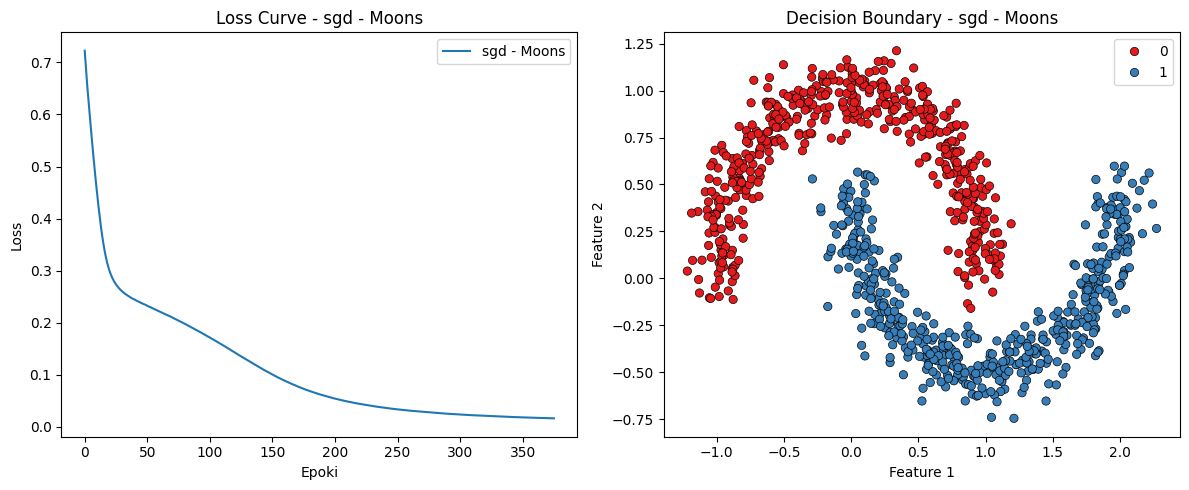

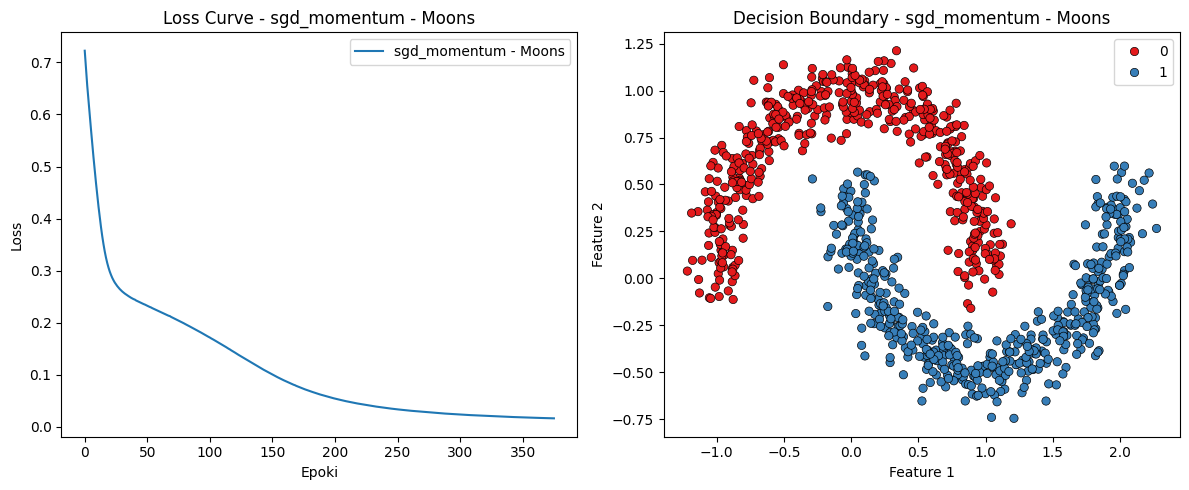

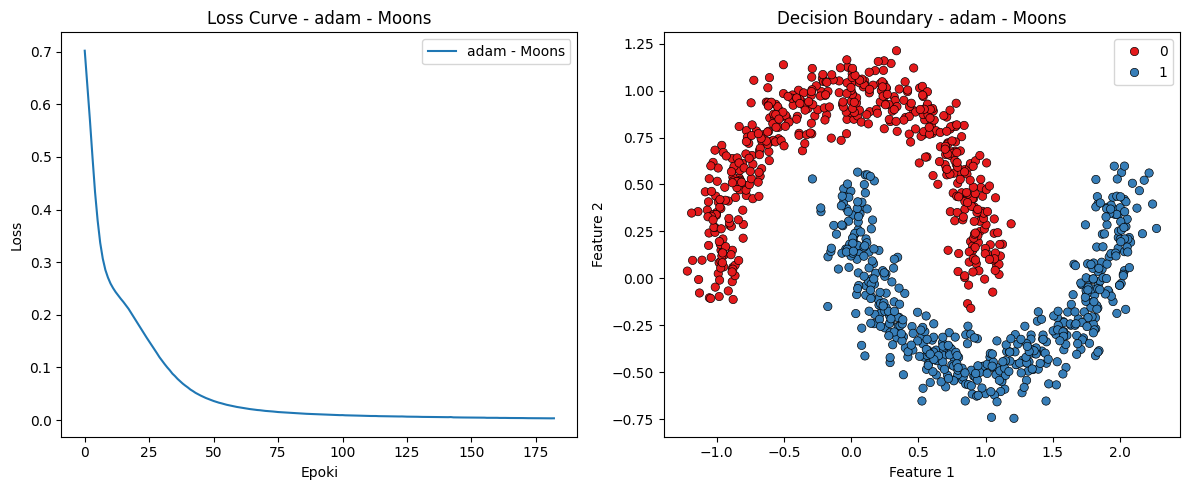

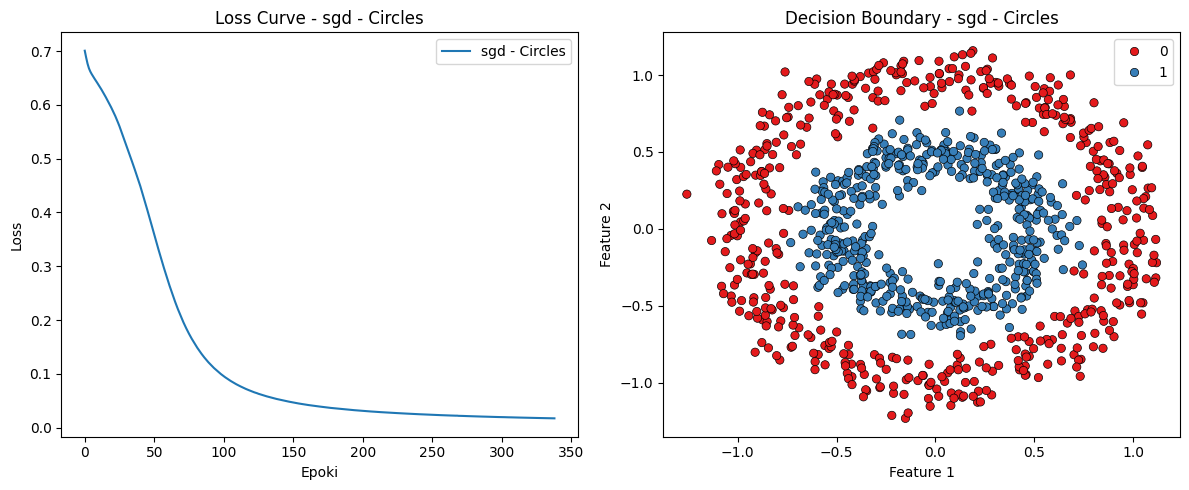

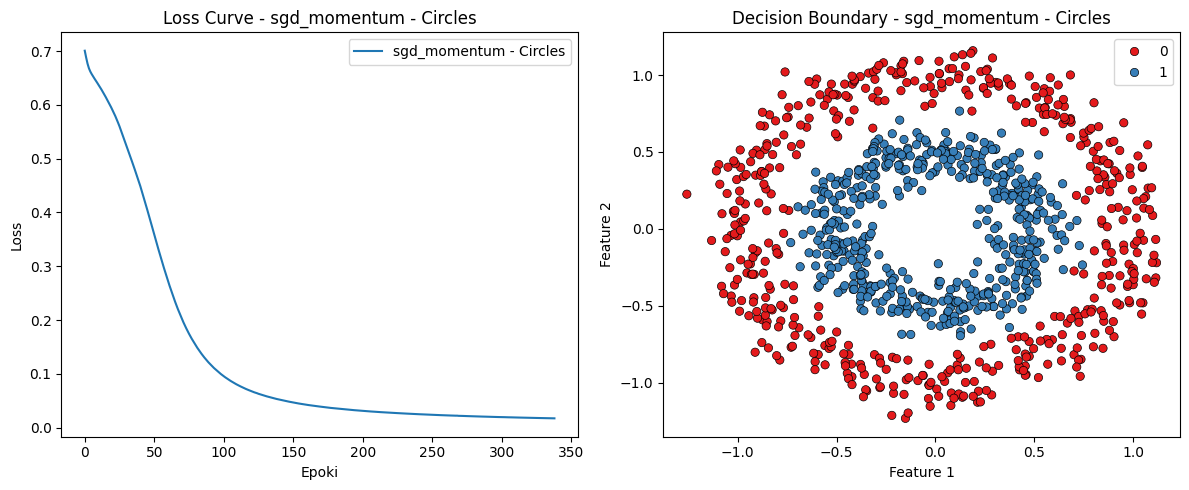

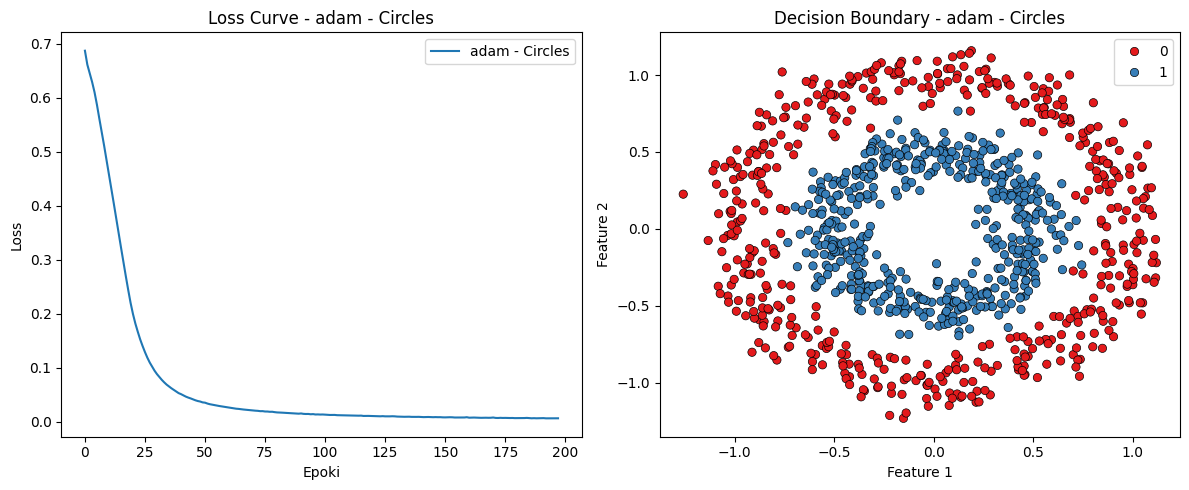

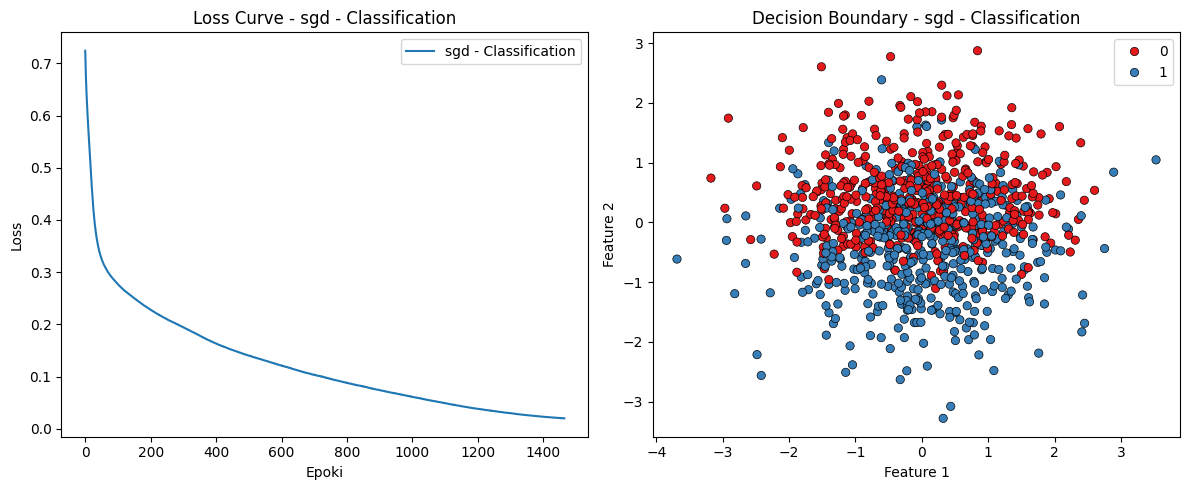

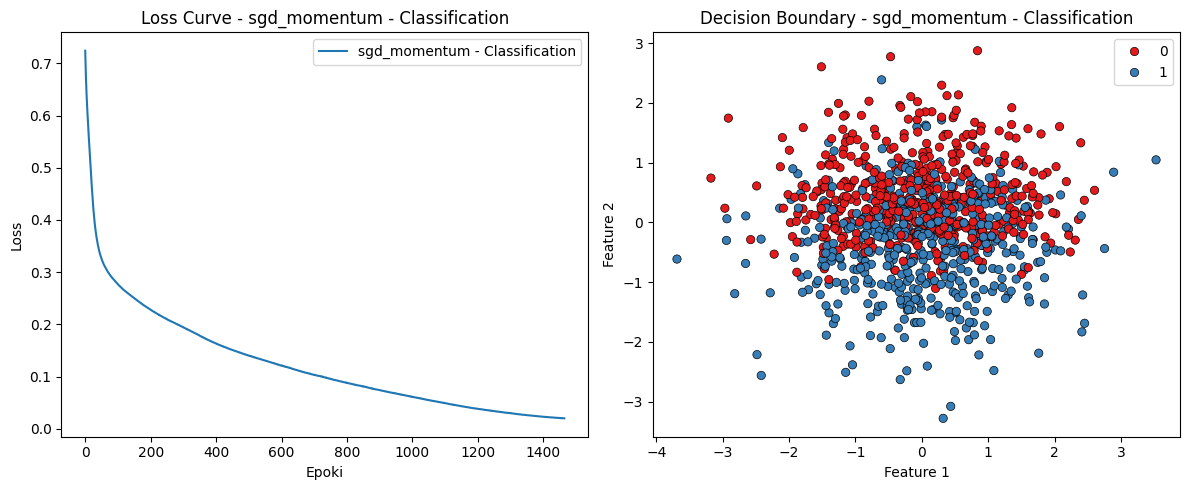

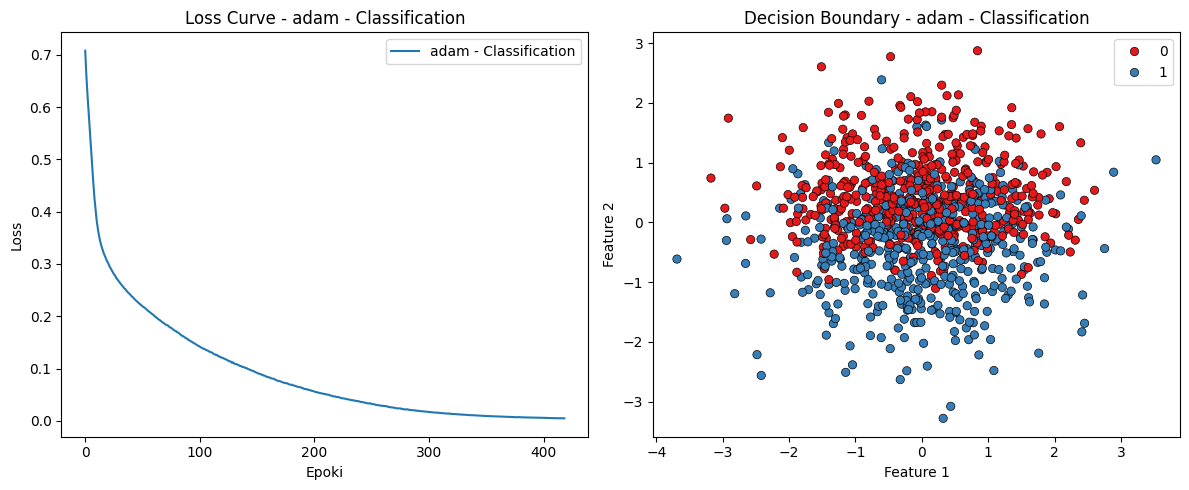

          Dataset     Optimizer  Accuracy
0           Moons           sgd     1.000
1           Moons  sgd_momentum     1.000
2           Moons          adam     1.000
3         Circles           sgd     0.975
4         Circles  sgd_momentum     0.975
5         Circles          adam     0.980
6  Classification           sgd     0.790
7  Classification  sgd_momentum     0.790
8  Classification          adam     0.805


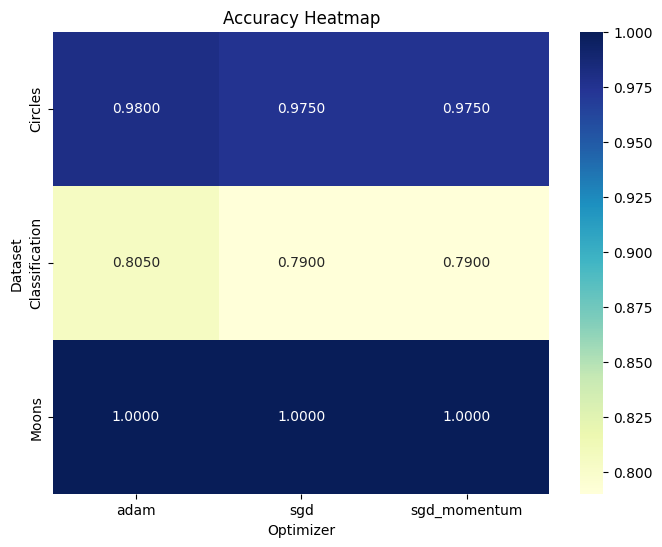

In [12]:
import numpy as np
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

datasets = {
    'Moons': make_moons(n_samples=1000, noise=0.1, random_state=42),
    'Circles': make_circles(n_samples=1000, noise=0.1, factor=0.5, random_state=42),
    'Classification': make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
}

optimizers = ['sgd', 'sgd_momentum','adam'] # 'rmsprop',
results = []

for name, (X, y) in datasets.items(): 
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    for opt in optimizers:
        if opt == 'sgd_momentum':
            model = MLPClassifier(hidden_layer_sizes=(16, 8), solver='sgd', momentum=0.9, max_iter=3000, batch_size=32, random_state=42)
        else:
            model = MLPClassifier(hidden_layer_sizes=(16, 8), solver=opt, max_iter=3000, batch_size=32, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        results.append({'Dataset': name, 'Optimizer': opt, 'Accuracy': accuracy})
       
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(model.loss_curve_, label=f'{opt} - {name}')
        plt.title(f'Loss Curve - {opt} - {name}')
        plt.xlabel('Epoki')
        plt.ylabel('Loss')
        plt.legend()
        plt.subplot(1, 2, 2)
        sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='Set1', edgecolor='k')
        plt.title(f'Decision Boundary - {opt} - {name}')
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.legend()
        plt.tight_layout()
        plt.show()

results_df = pd.DataFrame(results)
print(results_df)

heatmap_data = results_df.pivot(index='Dataset', columns='Optimizer', values='Accuracy')
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt=".4f")
plt.title('Accuracy Heatmap')
plt.show()


    
